In [1]:
import ast
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## Preprocessing

In [2]:
df = pd.read_csv('data/df.csv')

def extract_text(raw):
    """Join bullet-point list from all_items into a single string."""
    if not isinstance(raw, str) or not raw.strip():
        return None
    try:
        items = ast.literal_eval(raw)
        if isinstance(items, list):
            return ' '.join(str(x).strip() for x in items if x)
    except Exception:
        pass
    return raw

google_df['text'] = google_df['all_items'].apply(extract_text)
baidu_df['text']  = baidu_df['all_items'].apply(extract_text)

print(f'Google valid docs: {google_df["text"].notna().sum()} / {len(google_df)}')
print(f'Baidu  valid docs: {baidu_df["text"].notna().sum()} / {len(baidu_df)}')

Google valid docs: 89 / 118
Baidu  valid docs: 77 / 120


## BERTopic — shared setup

`paraphrase-multilingual-MiniLM-L12-v2` handles both English and Chinese.

In [3]:
EMBED_MODEL = 'paraphrase-multilingual-MiniLM-L12-v2'
embedder = SentenceTransformer(EMBED_MODEL)

def make_topic_model(n_neighbors=5, n_components=5, min_cluster_size=3):
    umap_model  = UMAP(n_neighbors=n_neighbors, n_components=n_components,
                       min_dist=0.0, metric='cosine', random_state=42)
    hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size, min_samples=1,
                            metric='euclidean', prediction_data=True)
    vectorizer  = CountVectorizer(min_df=1, ngram_range=(1, 2), max_features=5000)
    return BERTopic(
        embedding_model=embedder,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer,
        calculate_probabilities=True,
        verbose=False,
    )

print('Models configured.')

Models configured.


## Google — fit BERTopic

In [4]:
g_mask = google_df['text'].notna()
g_docs     = google_df.loc[g_mask, 'text'].tolist()
g_sections = google_df.loc[g_mask, 'section'].tolist()
g_topics_col = google_df.loc[g_mask, 'topic'].tolist()

g_model = make_topic_model()
g_topic_ids, g_probs = g_model.fit_transform(g_docs)

g_info = g_model.get_topic_info()
_g_out = g_info[g_info['Topic'] == -1]['Count'].values
g_n_out = int(_g_out[0]) if len(_g_out) else 0
print(f'Google: {len(g_info) - (1 if g_n_out else 0)} topics  |  {g_n_out} outlier docs')
g_info[g_info['Topic'] != -1][['Topic', 'Count', 'Name']].head(12)

Google: 13 topics  |  0 outlier docs


,Topic,Count,Name
0,0,14,0____
1,1,13,1_and_the_to_for
2,2,10,2_or_the_to_hiv
3,3,10,3_insulin_the_and_blood
4,4,7,4_mmhg_heart_hypertension_120
5,5,7,5_and_or_of_mental
6,6,6,6_or_lung_breathing_group
7,7,5,7_or_and_pain_persistent
8,8,4,8_surgery_breast_bottom_bottom surgery
9,9,4,9_gender_their gender_gender identity_identity


## Baidu / Chinese — fit BERTopic

In [5]:
b_mask = baidu_df['text'].notna()
b_docs     = baidu_df.loc[b_mask, 'text'].tolist()
b_sections = baidu_df.loc[b_mask, 'section'].tolist()
b_topics_col = baidu_df.loc[b_mask, 'topic'].tolist()

b_model = make_topic_model()
b_topic_ids, b_probs = b_model.fit_transform(b_docs)

b_info = b_model.get_topic_info()
_b_out = b_info[b_info['Topic'] == -1]['Count'].values
b_n_out = int(_b_out[0]) if len(_b_out) else 0
print(f'Baidu: {len(b_info) - (1 if b_n_out else 0)} topics  |  {b_n_out} outlier docs')
b_info[b_info['Topic'] != -1][['Topic', 'Count', 'Name']].head(12)

Baidu: 14 topics  |  0 outlier docs


,Topic,Count,Name
0,0,9,0_肥胖_多尿_多食_多饮
1,1,9,1_禁忌人群_关节炎_孕妇_皮肤感染
2,2,9,2_2官网_血糖血脂_心理与社会适应_方案
3,3,8,3_注意力不集中_脑雾_心悸_胸痛
4,4,8,4_清热解毒_比如_例如_适应症
5,5,7,5_1百科_或舒张压_140_头晕
6,6,5,6_如肺孢子菌肺炎_母婴传播_如卡波西肉瘤_无症状期
7,7,4,7_10_元至_后续护理 拔罐后注意保暖_拔罐后注意保暖
8,8,3,8_年生存率约_6百科_以上_等化学致癌物 或皮肤有
9,9,3,9_淋巴瘤_car_14_肺鳞癌 肉瘤


## Top topics per section — Google

In [6]:
def section_topic_table(topic_ids, sections, model, platform_label):
    """
    For each section, report the top-3 BERTopic clusters by doc count
    (outlier topic -1 excluded).  Returns a DataFrame.
    """
    df = pd.DataFrame({'bert_topic': topic_ids, 'section': sections})
    df = df[df['bert_topic'] != -1]

    topic_words = {
        tid: ', '.join(w for w, _ in model.get_topic(tid)[:6])
        for tid in df['bert_topic'].unique()
    }

    rows = []
    for section in SECTION_ORDER:
        sub = df[df['section'] == section]
        counts = sub['bert_topic'].value_counts().head(3)
        for tid, cnt in counts.items():
            rows.append({
                'section':       section,
                'bert_topic_id': tid,
                'keywords':      topic_words.get(tid, ''),
                'doc_count':     cnt,
            })
    result = pd.DataFrame(rows)
    print(f'\n=== {platform_label}: top topics per section ===')
    print(result.to_string(index=False))
    return result

g_section_topics = section_topic_table(g_topic_ids, g_sections, g_model, 'Google')


=== Google: top topics per section ===
          section  bert_topic_id                                  keywords  doc_count
common_conditions              3          insulin, the, and, blood, to, or         10
common_conditions              4 mmhg, heart, hypertension, 120, stage, 80          7
common_conditions             10      the, cells, or, bone, that, leukemia          3
    controversial              2            or, the, to, hiv, symptoms, of          4
    controversial              5   and, or, of, mental, mental health, the          4
    controversial              0                                , , , , ,           4
              tcm              1          and, the, to, for, cupping, used          5
              tcm              0                                , , , , ,           5
              tcm              2            or, the, to, hiv, symptoms, of          2
 legally_variable              1          and, the, to, for, cupping, used          5
 legally_varia

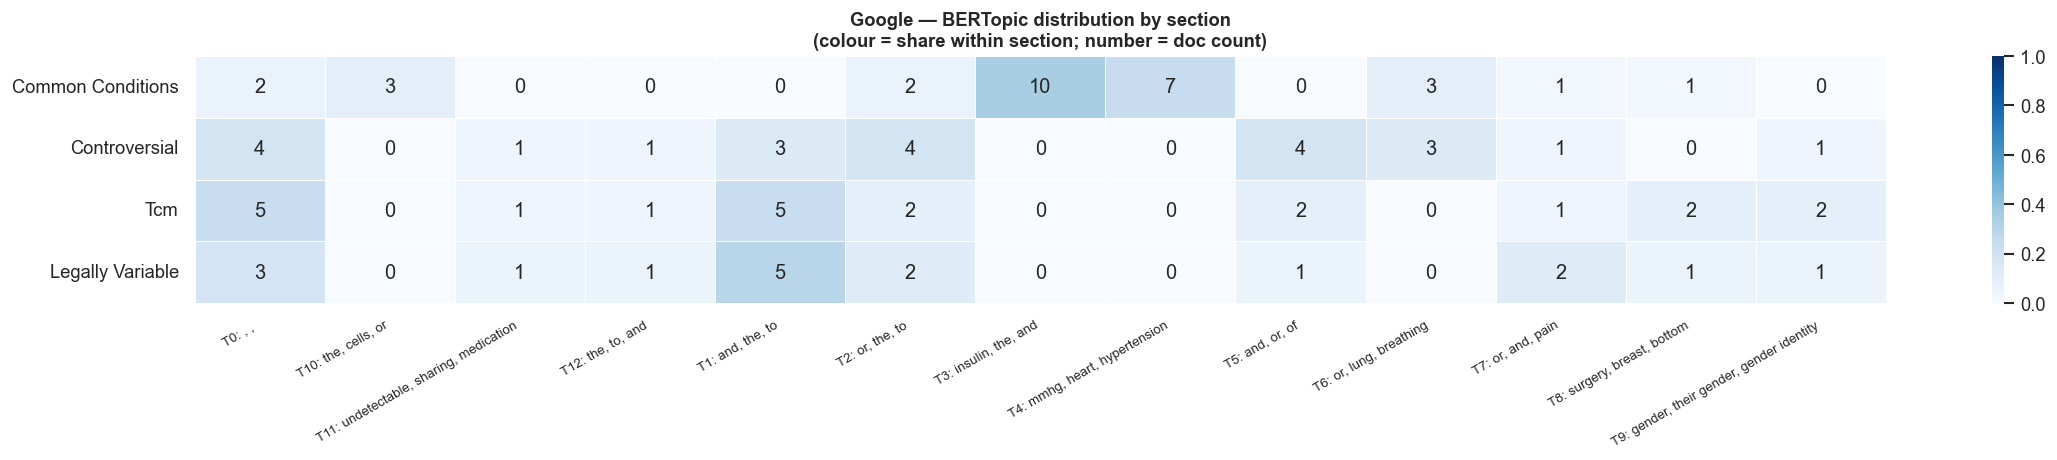

Saved fig_bertopic_google_sections.png


In [7]:
def plot_section_heatmap(topic_ids, sections, model, platform_label, color):
    df = pd.DataFrame({'bert_topic': topic_ids, 'section': sections})
    df = df[df['bert_topic'] != -1]

    topic_labels = {
        tid: f"T{tid}: {', '.join(w for w,_ in model.get_topic(tid)[:3])}"
        for tid in sorted(df['bert_topic'].unique())
    }
    df['topic_label'] = df['bert_topic'].map(topic_labels)

    heat = (
        df.groupby(['section', 'topic_label'])
          .size()
          .unstack(fill_value=0)
    )
    heat = heat.reindex(SECTION_ORDER).fillna(0)
    heat_pct = heat.div(heat.sum(axis=1), axis=0).fillna(0)

    fig, ax = plt.subplots(figsize=(max(10, len(heat.columns) * 1.5), 4))
    sns.heatmap(heat_pct, annot=heat.values, fmt='.0f',
                cmap=color, linewidths=0.5, ax=ax, vmin=0, vmax=1)
    ax.set_title(f'{platform_label} — BERTopic distribution by section\n'
                 f'(colour = share within section; number = doc count)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticklabels([s.replace('_', ' ').title() for s in SECTION_ORDER], rotation=0)
    plt.xticks(rotation=30, ha='right', fontsize=8)
    plt.tight_layout()
    fname = f'fig_bertopic_{platform_label.lower()}_sections.png'
    plt.savefig(fname)
    plt.show()
    print(f'Saved {fname}')

plot_section_heatmap(g_topic_ids, g_sections, g_model, 'Google', 'Blues')

## Top topics per section — Baidu (Chinese)

In [8]:
b_section_topics = section_topic_table(b_topic_ids, b_sections, b_model, 'Baidu')


=== Baidu: top topics per section ===
          section  bert_topic_id                                                            keywords  doc_count
common_conditions              0                                          肥胖, 多尿, 多食, 多饮, 三多一少, 高危人群          9
common_conditions              5                                     1百科, 或舒张压, 140, 头晕, arb, 80mmhg          7
common_conditions              8                         年生存率约, 6百科, 以上, 等化学致癌物 或皮肤有, 经常接触 沥青, 紫外线照射          3
    controversial              3                                          注意力不集中, 脑雾, 心悸, 胸痛, 头痛, 恶心          4
    controversial             11 生活方式调整, 日常生活功能, 均衡饮食 减少酒精或咖啡因摄入, 早期识别 记录情绪变化, 显著受损, 接纳情绪 允许自己感受负面情绪          3
    controversial             12                  社会支持, 社交变少, 表现, 空虚或绝望, 若有伤害自己或宝宝的念头 必须立即去精神科急诊, 空虚          3
              tcm              1                                     禁忌人群, 关节炎, 孕妇, 皮肤感染, 联合治疗, 疼痛管理          7
              tcm              4                                 

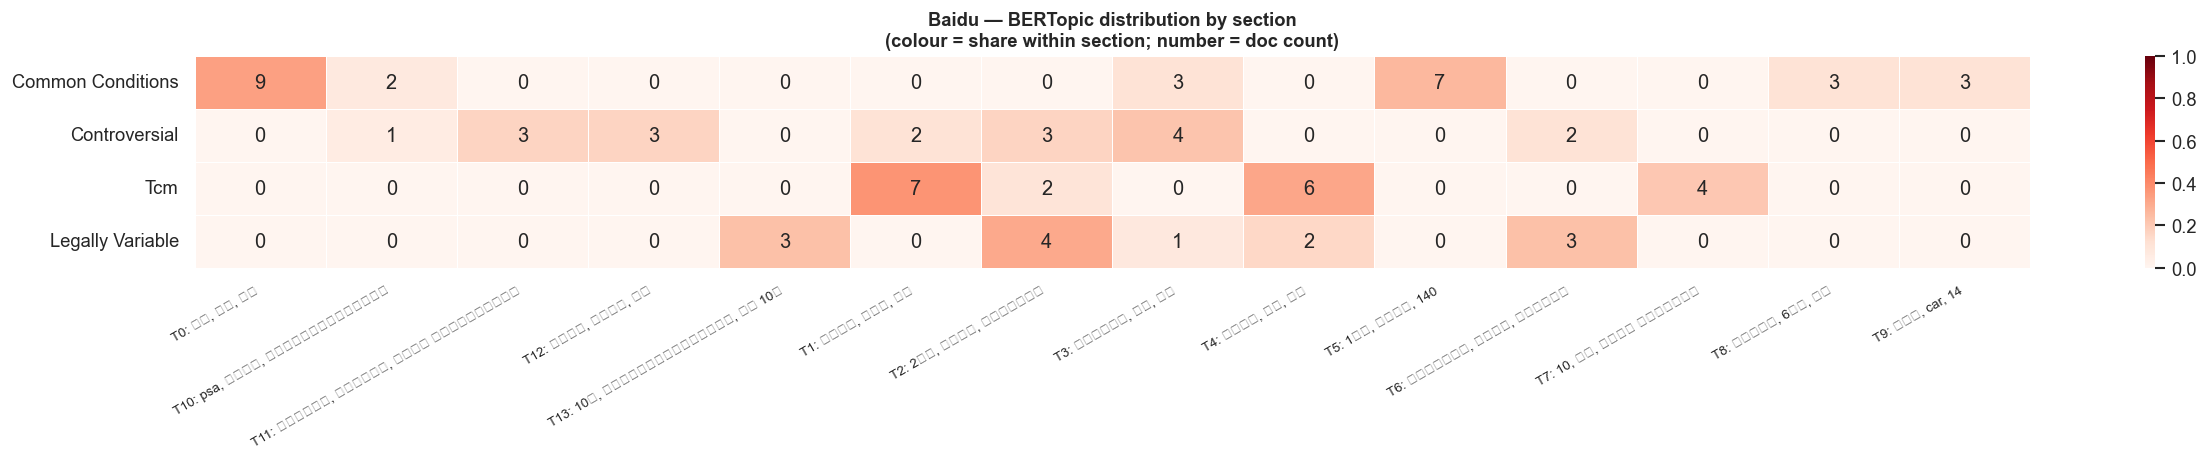

Saved fig_bertopic_baidu_sections.png


In [9]:
plot_section_heatmap(b_topic_ids, b_sections, b_model, 'Baidu', 'Reds')

## Bar charts — top keywords per dominant topic, by section

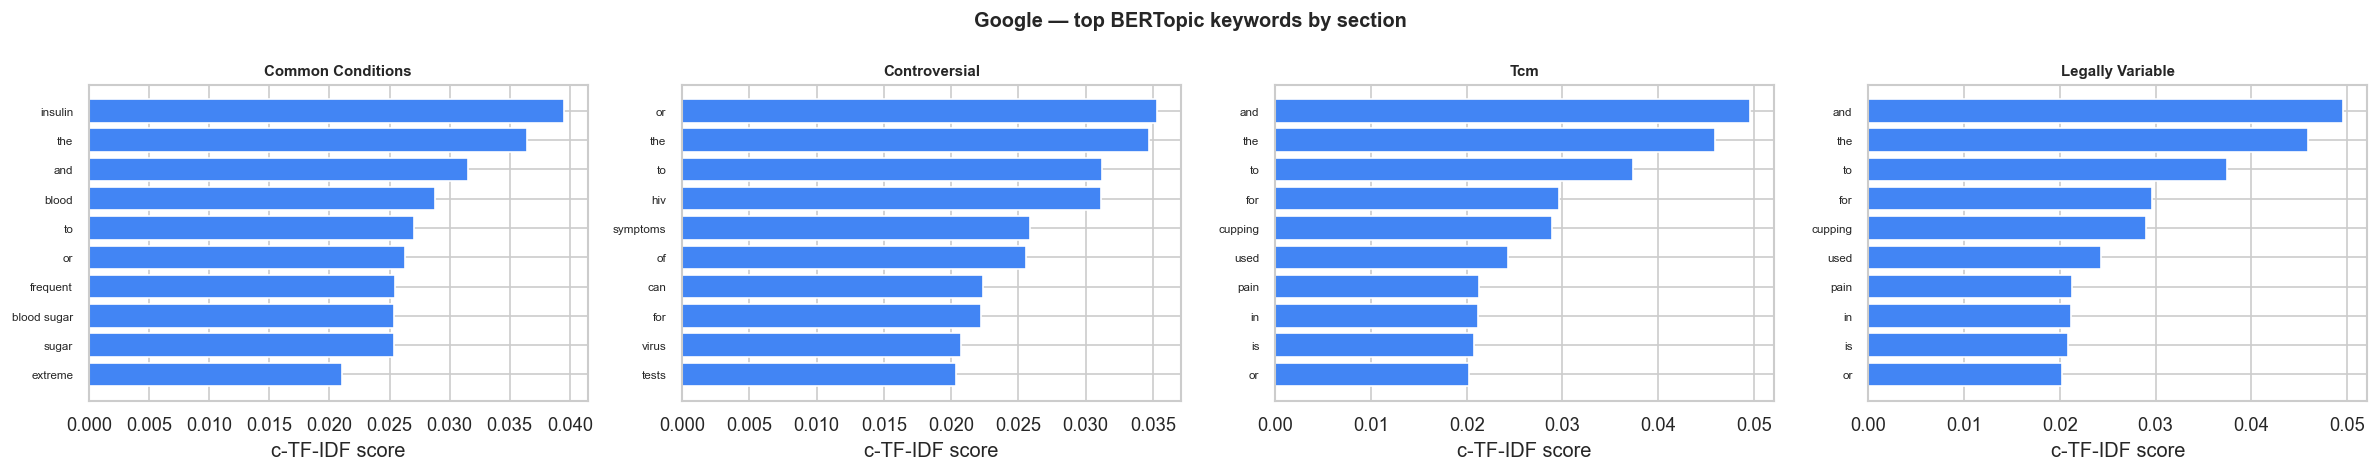

Saved fig_bertopic_google_keywords.png


In [10]:
def plot_top_keywords_by_section(topic_ids, sections, model, platform_label, bar_color):
    df = pd.DataFrame({'bert_topic': topic_ids, 'section': sections})
    df = df[df['bert_topic'] != -1]

    fig, axes = plt.subplots(1, len(SECTION_ORDER),
                             figsize=(5 * len(SECTION_ORDER), 4),
                             sharey=False)
    fig.suptitle(f'{platform_label} — top BERTopic keywords by section',
                 fontsize=12, fontweight='bold')

    for ax, section in zip(axes, SECTION_ORDER):
        sub = df[df['section'] == section]
        if sub.empty:
            ax.set_visible(False)
            continue
        dom_topic = sub['bert_topic'].value_counts().idxmax()
        words_scores = model.get_topic(dom_topic)[:10]
        words  = [w for w, _ in words_scores]
        scores = [s for _, s in words_scores]
        ax.barh(words[::-1], scores[::-1], color=bar_color)
        ax.set_title(section.replace('_', ' ').title(), fontsize=9, fontweight='bold')
        ax.set_xlabel('c-TF-IDF score')
        ax.tick_params(axis='y', labelsize=7)

    plt.tight_layout()
    fname = f'fig_bertopic_{platform_label.lower()}_keywords.png'
    plt.savefig(fname)
    plt.show()
    print(f'Saved {fname}')

plot_top_keywords_by_section(g_topic_ids, g_sections, g_model, 'Google', '#4285F4')

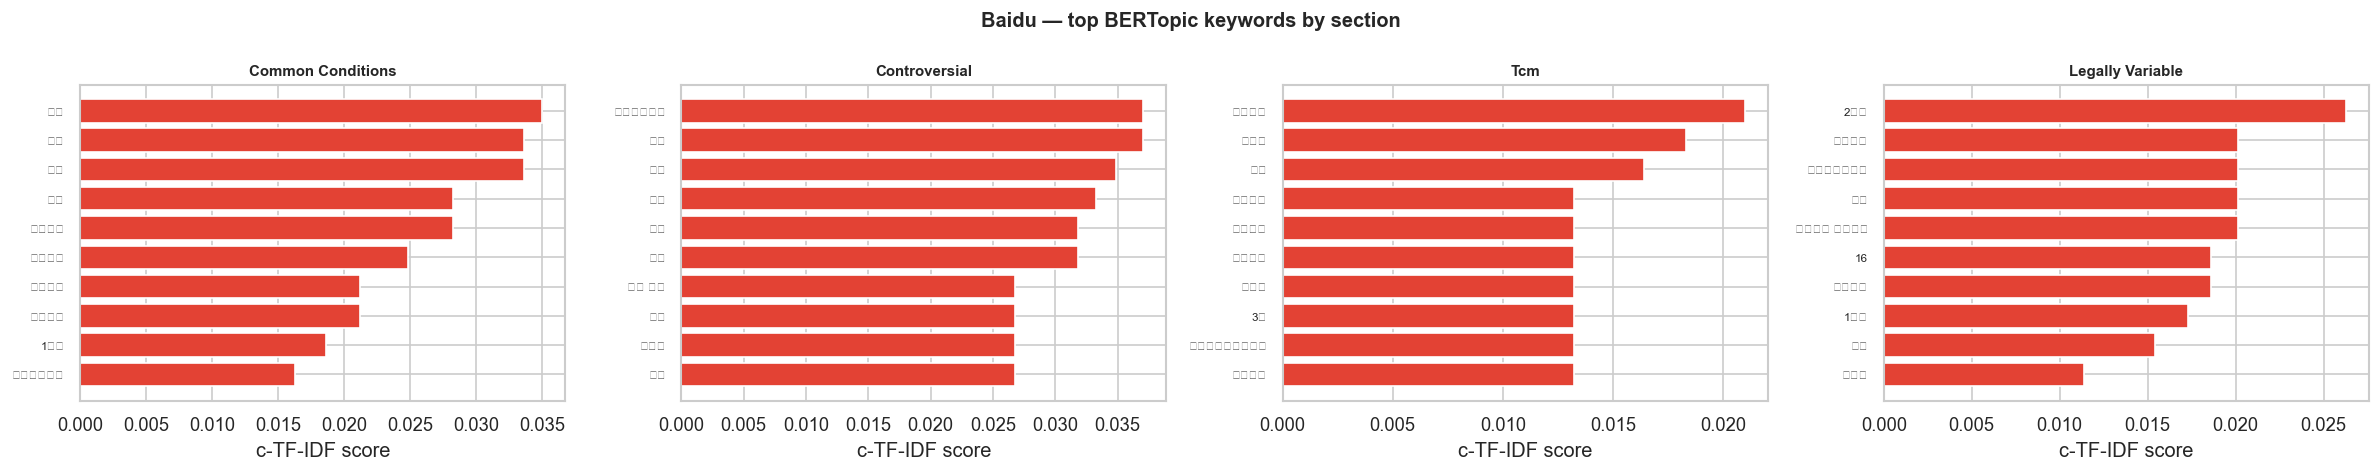

Saved fig_bertopic_baidu_keywords.png


In [11]:
plot_top_keywords_by_section(b_topic_ids, b_sections, b_model, 'Baidu', '#E34234')